# Sistema Inteligente de Estoque

## 1. Objetivo

Utilizar previsões de demanda para gerar recomendações inteligentes de estoque e reposição.

O foco deste notebook é apoiar decisões relacionadas a:
- compras
- estoque
- supply chain
- logística
- prevenção de ruptura
- redução de excesso de estoque

## 2. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3

from IPython.display import Markdown
from IPython.core.display import HTML
import math

import glob
import warnings
warnings.filterwarnings('ignore')

## 3. Congiguração Inicial

In [2]:
# Cor principal do projeto
PRIMARY_COLOR = "#50e550"
SECONDARY_COLORS = sns.light_palette(PRIMARY_COLOR, n_colors=5)

# Estilo geral
sns.set_theme(style="whitegrid")

# Tamanho padrão
plt.rcParams['figure.figsize'] = (10, 6)

# Fonte
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Carregamento dos Dados

In [3]:
df = pd.read_parquet(
    '../data/processed/category_forecast.parquet'
)

df.head()

,product_id,date,sales,day_of_week,day,month,year,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7,product_category_name,prediction,simulated_stock,rupture_risk_pct,overstock_pct
7433,7c1bd920dbdf22470b68bde975dd3ccf,2018-06-21,2,3,21,6,2018,25,1.0,1.0,1.0,1.000000,1.071429,0.000000,beleza_saude,1.162400,1.000000,16.240036,0.000000
7704,7fb04722aba7a2b632bac8f9819796f3,2018-06-21,1,3,21,6,2018,25,1.0,1.0,1.0,1.000000,1.000000,0.000000,beleza_saude,1.194523,1.000000,19.452345,0.000000
3522,3fbc0ef745950c7932d5f2a446189725,2018-06-21,2,3,21,6,2018,25,1.0,4.0,3.0,1.857143,2.928571,1.214986,beleza_saude,1.087907,3.072129,0.000000,64.587857
2503,341d85d688ecc3353cf2a968e7ad0dbf,2018-06-21,1,3,21,6,2018,25,1.0,2.0,1.0,1.285714,1.142857,0.487950,beleza_saude,1.306084,1.773664,0.000000,26.362375
1113,154e7e31ebfa092203795c972e5804a6,2018-06-21,2,3,21,6,2018,25,1.0,1.0,1.0,1.428571,1.214286,1.133893,beleza_saude,1.244355,2.562465,0.000000,51.439154


## 5. Verificação Inicial

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 2695 entries, 7433 to 11390
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_id             2695 non-null   str           
 1   date                   2695 non-null   datetime64[ms]
 2   sales                  2695 non-null   int64         
 3   day_of_week            2695 non-null   int32         
 4   day                    2695 non-null   int32         
 5   month                  2695 non-null   int32         
 6   year                   2695 non-null   int32         
 7   week_of_year           2695 non-null   UInt32        
 8   lag_1                  2695 non-null   float64       
 9   lag_7                  2695 non-null   float64       
 10  lag_14                 2695 non-null   float64       
 11  rolling_mean_7         2695 non-null   float64       
 12  rolling_mean_14        2695 non-null   float64       
 13  rolling_std_7  

## 6. Estoque Simulado

Como o dataset não possui estoque real, será utilizada uma simulação baseada na demanda histórica.

## 6.1 Estoque Inteligente

In [5]:
df['simulated_stock'] = (
    df['rolling_mean_7']
    +
    df['rolling_std_7']
)

## 6.2 Estoque de Segurança

O estoque de segurança ajuda a reduzir riscos de ruptura causados por variações inesperadas da demanda.

In [6]:
df['safety_stock'] = (
    df['rolling_std_7'] * 1.65
)

## 6.3 Lead Time

Tempo médio estimado entre pedido e reposição.

In [7]:
LEAD_TIME_DAYS = 7

## 6.4 Ponto de Reposição

Indica o momento ideal para realizar novas compras.

Fórmula

Ponto de Reposicao = (Demanda Media×Lead Time) + Estoque de Seguranca

In [8]:
df['average_demand'] = (
    df['rolling_mean_7']
)

In [9]:
df['reorder_point'] = (
    (
        df['average_demand']
        *
        LEAD_TIME_DAYS
    )
    +
    df['safety_stock']
)

## 6.5 Estoque Ideal

Representa o estoque recomendado considerando:
- demanda prevista
- variabilidade
- proteção operacional

In [10]:
df['ideal_stock'] = (
    df['prediction']
    +
    df['safety_stock']
)

## 6.6 Risco de Ruptura

In [11]:
df['rupture_risk_pct'] = (
    (
        df['prediction']
        -
        df['simulated_stock']
    )
    /
    df['simulated_stock']
)

df['rupture_risk_pct'] = (
    df['rupture_risk_pct']
    .clip(lower=0)
)

df['rupture_risk_pct'] *= 100

## 6.7 Overstock

In [12]:
df['overstock_pct'] = (
    (
        df['simulated_stock']
        -
        df['prediction']
    )
    /
    df['simulated_stock']
)

df['overstock_pct'] = (
    df['overstock_pct']
    .clip(lower=0)
)

df['overstock_pct'] *= 100

## 7. Recomendação de Compra

#### Recomendação Inteligente

Sistema automático de recomendação operacional.

In [13]:
conditions = [
    df['rupture_risk_pct'] > 50,
    
    (
        (df['rupture_risk_pct'] > 20)
        &
        (df['rupture_risk_pct'] <= 50)
    ),

    df['overstock_pct'] > 50
]

choices = [
    'Compra Urgente',
    'Reposição Moderada',
    'Reduzir Compras'
]

df['recommendation'] = np.select(
    conditions,
    choices,
    default='Estoque Saudável'
)

### 7.1 Distribuição das Recomendações

In [14]:
recommendation_counts = (
    df['recommendation']
    .value_counts()
)

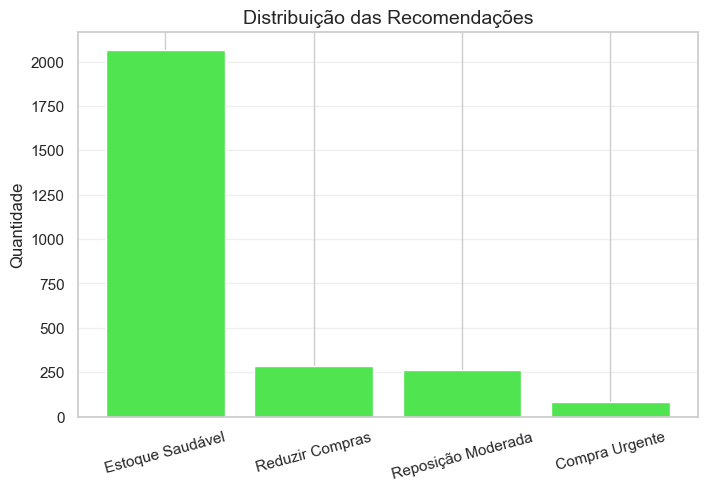

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    recommendation_counts.index,
    recommendation_counts.values,
    color=PRIMARY_COLOR
)

plt.title(
    'Distribuição das Recomendações'
)

plt.ylabel('Quantidade')

plt.xticks(rotation=15)

plt.grid(axis='y', alpha=0.3)

plt.show()

### 7.2 Categorias com Maior Risco

In [16]:
risk_by_category = (
    df.groupby(
        'product_category_name'
    )['rupture_risk_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

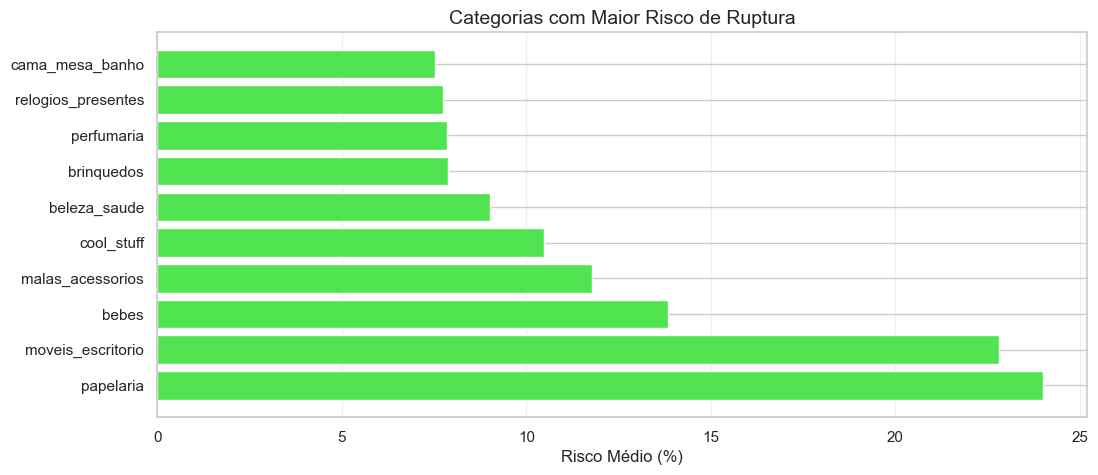

In [17]:
plt.figure(figsize=(12,5))

plt.barh(
    risk_by_category[
        'product_category_name'
    ][:10],

    risk_by_category[
        'rupture_risk_pct'
    ][:10],

    color=PRIMARY_COLOR
)

plt.title(
    'Categorias com Maior Risco de Ruptura'
)

plt.xlabel('Risco Médio (%)')

plt.grid(axis='x', alpha=0.3)

plt.show()

## 7.3 Categorias com Maior Overstock

In [18]:
overstock_by_category = (
    df.groupby(
        'product_category_name'
    )['overstock_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

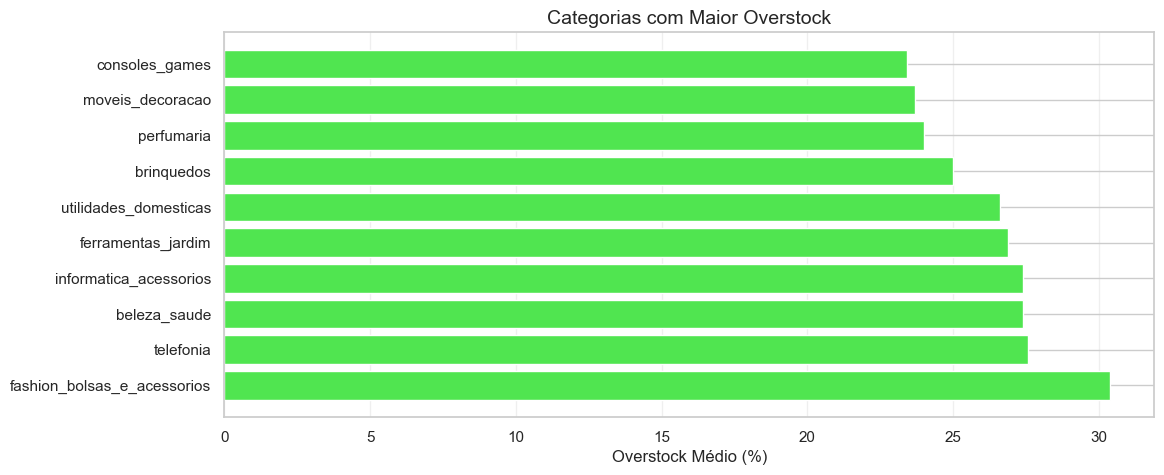

In [19]:
plt.figure(figsize=(12,5))

plt.barh(
    overstock_by_category[
        'product_category_name'
    ][:10],

    overstock_by_category[
        'overstock_pct'
    ][:10],

    color=PRIMARY_COLOR
)

plt.title(
    'Categorias com Maior Overstock'
)

plt.xlabel('Overstock Médio (%)')

plt.grid(axis='x', alpha=0.3)

plt.show()

## 8. Produtos Críticos 

Deve ser comprados urgentemente

In [20]:
critical_products = df[
    df['rupture_risk_pct'] > 50
]

critical_products[
    [   'product_id',
        'product_category_name',
        'prediction',
        'simulated_stock',
        'rupture_risk_pct',
        'recommendation'
    ]
].head()

,product_id,product_category_name,prediction,simulated_stock,rupture_risk_pct,recommendation
10668,bb50f2e236e5eea0100680137654686c,beleza_saude,1.505835,1.0,50.583529,Compra Urgente
10294,b38b25d838ae0b8385e8cc68b9017644,beleza_saude,1.556617,1.0,55.661750,Compra Urgente
45,016711f78a6a87696645db0a6a834826,beleza_saude,1.528137,1.0,52.813745,Compra Urgente
463,0a4093a4af429dc0a9334300e5c13ae5,beleza_saude,1.505835,1.0,50.583529,Compra Urgente
7713,7fb04722aba7a2b632bac8f9819796f3,beleza_saude,1.505835,1.0,50.583529,Compra Urgente


## 9. Produtos com excesso de estoque

In [21]:
overstock_products = (
    df.groupby(
        [
            'product_id',
            'product_category_name'
        ]
    )['overstock_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

overstock_products.head(10)

,product_id,product_category_name,overstock_pct
0,b623b7cb05ee3248fbe4a6ecbeed79a4,brinquedos,87.258224
1,e7cc48a9daff5436f63d3aad9426f28b,telefonia,78.222388
2,19421075ae0b585f2dc13ff149e2119d,esporte_lazer,66.215756
3,9f1c3e71d56894398a42b050b07f1baa,cool_stuff,63.698996
4,e44f675b60b3a3a2453ec36421e06f0f,esporte_lazer,62.835014
5,1d3ecbda18167c766a3381fd16108e4a,esporte_lazer,61.557606
6,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,60.784180
7,4b703444923b5e57bb73ba343f5ebab7,cama_mesa_banho,55.809678
8,d017a2151d543a9885604dc62a3d9dcc,fashion_bolsas_e_acessorios,54.471453
9,474bb6b54fc608ca71059a6c4f7ecda3,eletronicos,54.034003


In [22]:
top_overstock = overstock_products.head(10)
top_overstock['product_label'] = (
    top_overstock['product_category_name']
    +
    ' | '
    +
    top_overstock['product_id'].str[:8]
)

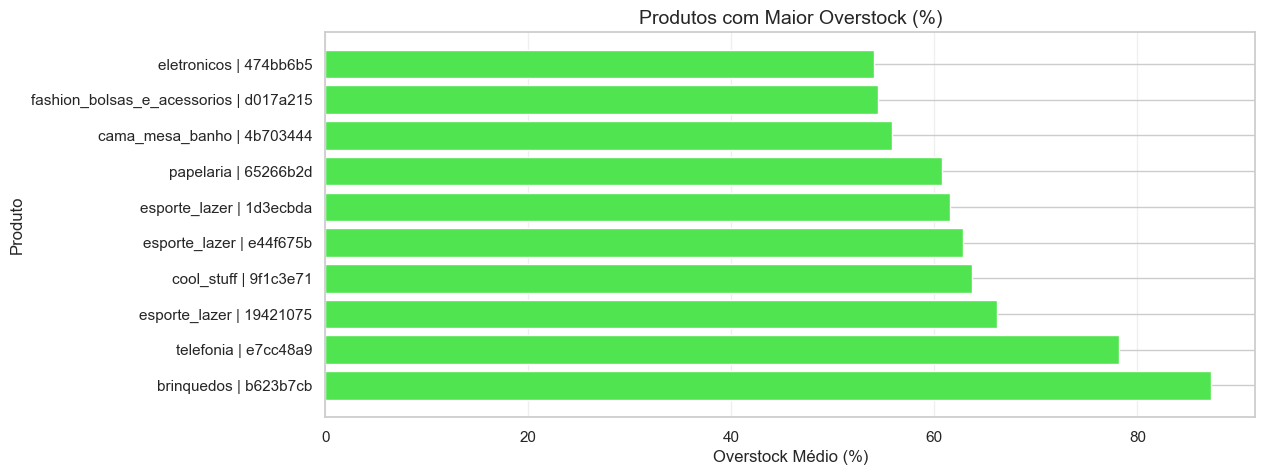

In [23]:
plt.figure(figsize=(12,5))

plt.barh(
    top_overstock['product_label'],
    top_overstock['overstock_pct'],
    color=PRIMARY_COLOR
)

plt.title(
    'Produtos com Maior Overstock (%)'
)

plt.xlabel('Overstock Médio (%)')

plt.ylabel('Produto')

plt.grid(axis='x', alpha=0.3)

plt.show()

Produtos com alto overstock apresentam estoque acima da demanda prevista, indicando possível excesso de armazenagem e baixa eficiência operacional.

Esses produtos podem demandar:
- redução de compras
- promoções
- revisão da política de estoque
- redistribuição logística

In [24]:
df['inventory_health_score'] = (
    100
    -
    df['rupture_risk_pct']
    -
    df['overstock_pct']
)

In [25]:
overstock_products = df[
    df['overstock_pct'] > 50
]

In [26]:
overstock_products[
    [
        'product_id',
        'product_category_name',
        'prediction',
        'simulated_stock',
        'overstock_pct',
        'recommendation'
    ]
].head()

,product_id,product_category_name,prediction,simulated_stock,overstock_pct,recommendation
3522,3fbc0ef745950c7932d5f2a446189725,beleza_saude,1.087907,3.072129,64.587857,Reduzir Compras
1113,154e7e31ebfa092203795c972e5804a6,beleza_saude,1.244355,2.562465,51.439154,Reduzir Compras
2251,2b4609f8948be18874494203496bc318,beleza_saude,1.213832,2.562465,52.630291,Reduzir Compras
1440,19c91ef95d509ea33eda93495c4d3481,beleza_saude,1.120460,2.756878,59.357644,Reduzir Compras
1441,19c91ef95d509ea33eda93495c4d3481,beleza_saude,1.270699,2.816497,54.883714,Reduzir Compras


In [27]:
overstock_products = df[
    df['overstock_pct'] > 50
]

overstock_products = (
    overstock_products
    .sort_values(
        'overstock_pct',
        ascending=False
    )
)

overstock_products[
    [
        'product_id',
        'product_category_name',
        'prediction',
        'simulated_stock',
        'overstock_pct',
        'recommendation'
    ]
].head(10)

,product_id,product_category_name,prediction,simulated_stock,overstock_pct,recommendation
10439,b623b7cb05ee3248fbe4a6ecbeed79a4,brinquedos,0.880979,9.163978,90.386501,Reduzir Compras
10440,b623b7cb05ee3248fbe4a6ecbeed79a4,brinquedos,1.122833,9.223165,87.825941,Reduzir Compras
10438,b623b7cb05ee3248fbe4a6ecbeed79a4,brinquedos,1.154761,9.163978,87.398915,Reduzir Compras
13257,e7cc48a9daff5436f63d3aad9426f28b,telefonia,1.566752,12.152248,87.107309,Reduzir Compras
13260,e7cc48a9daff5436f63d3aad9426f28b,telefonia,1.729361,11.904560,85.473123,Reduzir Compras
13262,e7cc48a9daff5436f63d3aad9426f28b,telefonia,1.689362,11.614126,85.454245,Reduzir Compras
13256,e7cc48a9daff5436f63d3aad9426f28b,telefonia,1.564350,10.394538,84.950268,Reduzir Compras
3794,422879e10f46682990de24d770e7f83d,ferramentas_jardim,0.976072,6.274873,84.444757,Reduzir Compras
10441,b623b7cb05ee3248fbe4a6ecbeed79a4,brinquedos,1.519246,9.163978,83.421541,Reduzir Compras
13259,e7cc48a9daff5436f63d3aad9426f28b,telefonia,2.037380,11.904560,82.885720,Reduzir Compras


## 10. Salvando Resultados Final

principal dataset do dashboard

principal dataset da aplicação

dataset executivo

In [28]:

df.to_parquet(
    '../data/processed/intelligent_inventory.parquet'
)

Produtos críticos (ruptura)

In [29]:
critical_products.to_parquet(
    '../data/processed/critical_products.parquet'
)

Produtos em overstock

In [30]:
overstock_products.to_parquet(
    '../data/processed/overstock_products.parquet'
)

Salvar risco por categoria

In [31]:
risk_by_category.to_parquet(
    '../data/processed/risk_by_category.parquet'
)

Salvar overstock por categoria

In [32]:
overstock_by_category.to_parquet(
    '../data/processed/overstock_by_category.parquet'
)

## 11. Insights 

#####  💡 Insights Estratégicos

O sistema inteligente permitiu identificar:
- categorias com maior risco de ruptura
- categorias com excesso de estoque
- produtos críticos
- oportunidades de otimização logística

As recomendações geradas podem apoiar:
- planejamento de compras
- reposição automática
- redução de custos
- redução de desperdícios
- melhoria da disponibilidade de produtos

## 12. Conclusão

O projeto evoluiu de uma simples previsão de demanda para um sistema inteligente de apoio à decisão em supply chain.

O sistema desenvolvido foi capaz de:
- prever demanda
- detectar riscos operacionais
- calcular estoque ideal
- recomendar ações de reposição
- reduzir riscos de ruptura e overstock

Essa abordagem contribui para:
- maior eficiência operacional
- redução de custos
- melhor experiência do cliente
- consumo mais inteligente e sustentável

## proximo passo 

Dashboard com:

KPIs

ruptura

overstock

recomendações

gráficos

filtros